In [2]:
 from google.colab import files

uploaded = files.upload()

Saving traffic.csv.zip to traffic.csv.zip


In [3]:
import zipfile

with zipfile.ZipFile('traffic.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully")

Dataset extracted successfully


In [4]:
import os

os.listdir()

['.config', 'traffic.csv.zip', 'traffic.csv', 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv("traffic.csv")

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [7]:
df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [9]:
df["country"] = df["country"].fillna("Unknown")
df["city"] = df["city"].fillna("Unknown")
df["artist"] = df["artist"].fillna("Unknown")
df["album"] = df["album"].fillna("Unknown")
df["track"] = df["track"].fillna("Unknown")
df["isrc"] = df["isrc"].fillna("Unknown")

df.isnull().sum()

,0
event,0
date,0
country,0
city,0
artist,0
album,0
track,0
isrc,0
linkid,0


In [10]:
df["date"] = pd.to_datetime(df["date"])

df.dtypes

,0
event,object
date,datetime64[ns]
country,object
city,object
artist,object
album,object
track,object
isrc,object
linkid,object


In [11]:
total_events = len(df)

print("Total Events:", total_events)

Total Events: 226278


In [12]:
unique_links = df["linkid"].nunique()

print("Unique Links:", unique_links)

Unique Links: 3839


In [13]:
unique_countries = df["country"].nunique()

print("Unique Countries:", unique_countries)

Unique Countries: 212


In [14]:
unique_cities = df["city"].nunique()

print("Unique Cities:", unique_cities)

Unique Cities: 11993


In [15]:
event_counts = df["event"].value_counts()

print(event_counts)

event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64


In [16]:
top_countries = df["country"].value_counts().head(10)

print(top_countries)

country
Saudi Arabia            47334
India                   42992
United States           32558
France                  15661
Iraq                     8260
United Kingdom           5970
Pakistan                 5644
Germany                  4794
United Arab Emirates     3702
Turkey                   3514
Name: count, dtype: int64


In [17]:
top_cities = df["city"].value_counts().head(10)

print(top_cities)

city
Jeddah         22791
Riyadh         17454
Unknown        16672
Hyderabad       3682
Dammam          3276
Erbil           3105
Kuwait City     3010
Lucknow         2808
Muscat          2717
Delhi           2567
Name: count, dtype: int64


In [18]:
top_artists = df["artist"].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          40841
Anne-Marie                                                      10650
Tundra Beats                                                     9751
Surf Mesa, Emilee                                                7533
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     5512
Reyanna Maria                                                    5437
Shawn Mendes, Tainy                                              5409
50 Cent, Olivia                                                  5367
Roddy Ricch                                                      5093
Olivia Rodrigo                                                   4115
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt

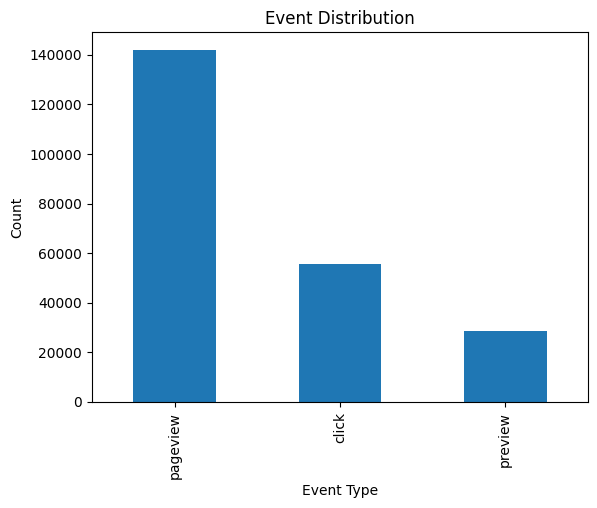

In [20]:
event_counts.plot(kind="bar")

plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

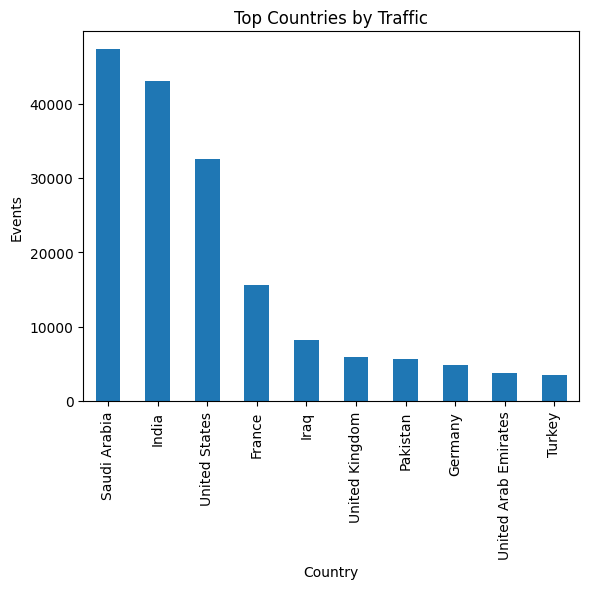

In [21]:
top_countries.plot(kind="bar")

plt.title("Top Countries by Traffic")
plt.xlabel("Country")
plt.ylabel("Events")
plt.show()

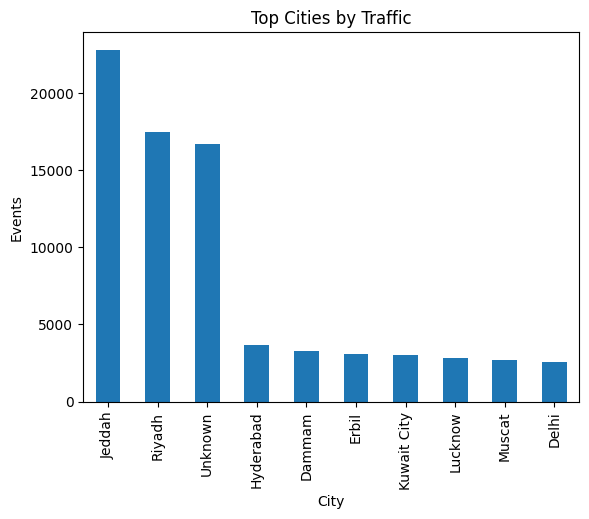

In [22]:
top_cities.plot(kind="bar")

plt.title("Top Cities by Traffic")
plt.xlabel("City")
plt.ylabel("Events")
plt.show()

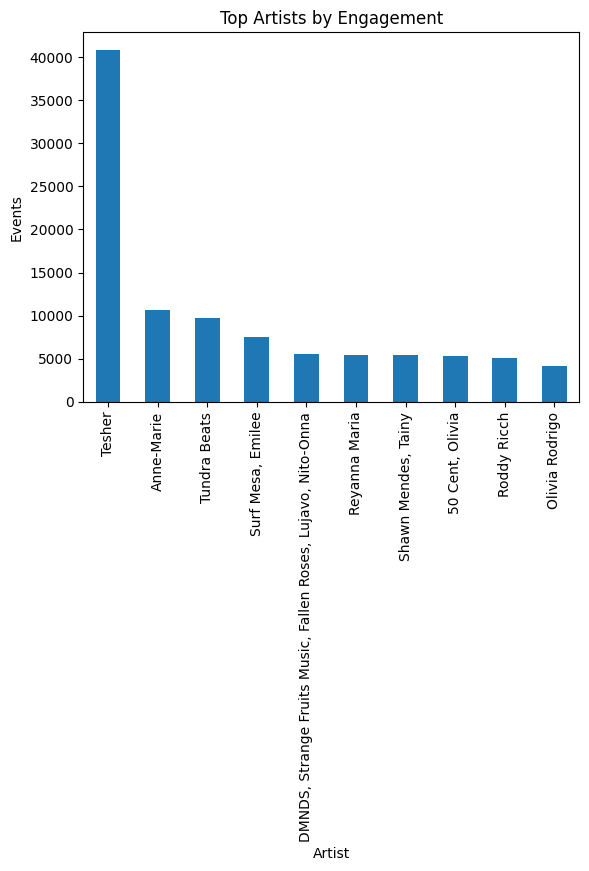

In [23]:
top_artists.plot(kind="bar")

plt.title("Top Artists by Engagement")
plt.xlabel("Artist")
plt.ylabel("Events")
plt.show()

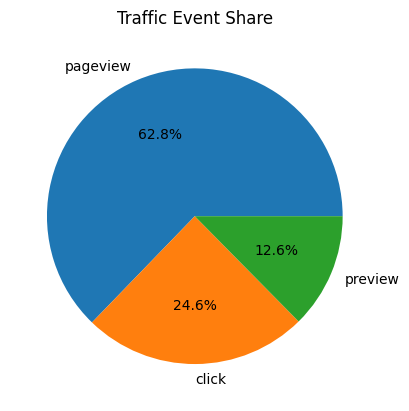

In [24]:
event_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Traffic Event Share")
plt.ylabel("")
plt.show()

In [25]:
df["Month"] = df["date"].dt.month

monthly_events = df.groupby("Month").size()

print(monthly_events)

Month
8    226278
dtype: int64
